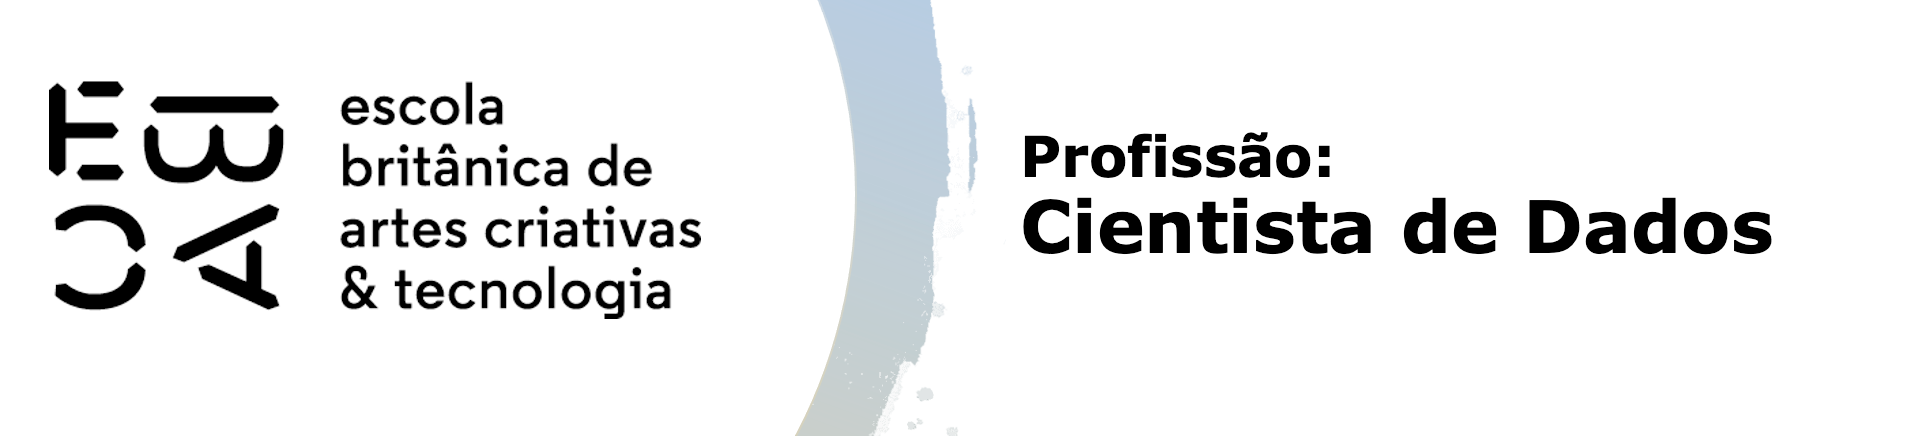

# Tarefa II

Ainda sobre a base da NFP vista na tarefa passada:

|Campo|Descrição|
|:-|:-|
|CNPJ emit.| CNPJ do emitente da nota|
|Emitente| Nome fantasia do emitente da nota|
|No.| Número da nota fiscal|
|Data Emissão| Data de emissão da nota fiscal|
|Valor NF| Valor da nota fiscal|
|Data Registro| Data de registro no sistema da NFP|
|Créditos| Valor dos créditos (doação)|
|Situação do Crédito| Se o crédito já foi pago, está sendo processado etc.|
|Ano| Ano da emissão da nota|
|Semestre| Semestre da emissão da nota|
|Retorno| Valor do crédito dividido pelo valor da nota|
|flag_credito| Indicadora se a nota possui crédito positivo|
|categoria| Categorização da nota |

**OBJETIVO:** Algumas notas não dão retorno, o que pode ocorrer por diversos motivos, um deles seria a ocorrência de produtos não incentivados como cigarros e bebidas alcólicas. O nosso objetivo é tentar prever que tipo de nota tem maior ou menor propensão a fornecer créditos.

**Observação**: Esta é uma base real, havendo características de acordo. Pode haver uma variabilidade difícil de explicar, em parte por causa de uma freqüência de notas inconstante no tempo (por diversos motivos), em parte por haverem informações importantes, protegidas pela LGPD, não constantes na base, que pode interferir no crédito gerado, o que vai ocasionar uma variabilidade difícil de se explicar. *Welcome to the jungle*, A vida real é assim :)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carregando a base

try:
    df = pd.read_feather('NFP.ftr')
except FileNotFoundError:
    df = pd.read_pickle('base_nfp.pkl')

print('Quantidade de linhas e colunas da base:', df.shape)
df.head()

Quantidade de linhas e colunas da base: (187646, 13)


,CNPJ emit.,Emitente,No.,Data Emissão,Valor NF,Data Registro,Créditos,Situação do Crédito,Ano,Semestre,Retorno,flag_credito,categoria
0,03.476.811/0741-98,DIA BRASIL SOCIEDADE LIMITADA,537,2017-06-30,24.68,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Mercado
1,43.101.310/0001-05,AUTO POSTO ZANWAL LTDA EPP,2894,2017-06-30,50.00,2017-06-30,0.00,Liberado,2017,1,0.000000,0,Auto posto
2,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,699,2017-06-30,27.00,2017-06-30,0.44,Liberado,2017,1,0.016296,1,Restaurantes
3,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,698,2017-06-30,111.50,2017-06-30,1.81,Liberado,2017,1,0.016233,1,Restaurantes
4,23.750.257/0001-66,OFICINA DO TRIGO PASTIFICIO PANIFICADORA BAR E RE,694,2017-06-30,125.00,2017-06-30,2.03,Liberado,2017,1,0.016240,1,Restaurantes


## Criando variáveis

**Variáveis temporais**: É possível que haja alguma regra de liberação de créditos de acordo com o dia do mês, o dia da semana, fim de semana (sim ou não), ou até alterações temporais da regra. Vamos criar as seguintes variáveis para testar estas hipóteses:

- Dia da semana
- Dummy para fim de semana
- Dia do mês
- Mês (já na base)
- Trimestre
- Ano (já na base)

**Valor da nota**: Vamos criar também algumas variáveis para resumir o valor da nota, e posteriormente criar uma intuição sobre categorizações de variáveis contínuas.

- Crie categorizações da variável ```Valor NF```, por quantís, em 5, 10, 20 e 50 categorias.

In [2]:
# Converter a coluna de data para o formato datetime
df['Data Emissão'] = pd.to_datetime(df['Data Emissão'])

# Criar variáveis temporais a partir da data de emissão
df['dia_semana'] = df['Data Emissão'].dt.day_name()
df['fim_semana'] = df['Data Emissão'].dt.dayofweek.isin([5, 6]).astype(int)
df['dia_mes'] = df['Data Emissão'].dt.day
df['mes'] = df['Data Emissão'].dt.month
df['trimestre'] = df['Data Emissão'].dt.quarter
df['ano_emissao'] = df['Data Emissão'].dt.year

# Criar categorizações da variável Valor NF por quantis
df['valor_nf_5_cat'] = pd.qcut(df['Valor NF'], q=5, duplicates='drop')
df['valor_nf_10_cat'] = pd.qcut(df['Valor NF'], q=10, duplicates='drop')
df['valor_nf_20_cat'] = pd.qcut(df['Valor NF'], q=20, duplicates='drop')
df['valor_nf_50_cat'] = pd.qcut(df['Valor NF'], q=50, duplicates='drop')

print('Visualização das variáveis criadas:')
df[['Data Emissão', 'Valor NF', 'flag_credito', 'dia_semana', 'fim_semana', 
    'dia_mes', 'mes', 'trimestre', 'ano_emissao', 
    'valor_nf_5_cat', 'valor_nf_10_cat', 'valor_nf_20_cat', 'valor_nf_50_cat']].head()

Visualização das variáveis criadas:


,Data Emissão,Valor NF,flag_credito,dia_semana,fim_semana,dia_mes,mes,trimestre,ano_emissao,valor_nf_5_cat,valor_nf_10_cat,valor_nf_20_cat,valor_nf_50_cat
0,2017-06-30,24.68,0,Friday,0,30,6,2,2017,"(13.36, 28.61]","(20.29, 28.61]","(24.5, 28.61]","(23.62, 25.14]"
1,2017-06-30,50.00,0,Friday,0,30,6,2,2017,"(28.61, 55.0]","(38.88, 55.0]","(46.028, 55.0]","(48.0, 50.72]"
2,2017-06-30,27.00,1,Friday,0,30,6,2,2017,"(13.36, 28.61]","(20.29, 28.61]","(24.5, 28.61]","(26.9, 28.61]"
3,2017-06-30,111.50,1,Friday,0,30,6,2,2017,"(55.0, 131.36]","(81.8, 131.36]","(101.48, 131.36]","(107.04, 119.5]"
4,2017-06-30,125.00,1,Friday,0,30,6,2,2017,"(55.0, 131.36]","(81.8, 131.36]","(101.48, 131.36]","(119.5, 131.36]"


## Calcule o IV de todas essas variáveis

Sugestão: Construa um metadados e tente utilizar uma função como a que foi utilizada durante a aula. Você vai conseguir fazer esse cálculo para as variáveis uma a uma, mas em casos reais em que vamos mais além na criação de variáveis, podemos ter centenas, ou até milhares de variáveis, esses cálculos *precisam* ser automáticos nesses casos.

In [12]:
# Construindo metadados para as variáveis criadas

metadados = pd.DataFrame({'dtype': df.dtypes})

metadados['papel'] = 'covariavel'

# Variáveis que não devem entrar na análise de IV como explicativas
metadados.loc['CNPJ emit.', 'papel'] = 'identificador'
metadados.loc['Emitente', 'papel'] = 'identificador'
metadados.loc['No.', 'papel'] = 'identificador'
metadados.loc['Data Emissão', 'papel'] = 'data'
metadados.loc['Data Registro', 'papel'] = 'data'
metadados.loc['Créditos', 'papel'] = 'resposta_auxiliar'
metadados.loc['Situação do Crédito', 'papel'] = 'resposta_auxiliar'
metadados.loc['Retorno', 'papel'] = 'resposta_auxiliar'
metadados.loc['flag_credito', 'papel'] = 'resposta'

# Variáveis criadas que serão avaliadas
variaveis_criadas = [
    'dia_semana',
    'fim_semana',
    'dia_mes',
    'mes',
    'trimestre',
    'ano_emissao',
    'valor_nf_5_cat',
    'valor_nf_10_cat',
    'valor_nf_20_cat',
    'valor_nf_50_cat'
]

metadados['nunique'] = df.nunique()

print('Metadados das variáveis criadas:')
metadados.loc[variaveis_criadas + ['flag_credito']]

Metadados das variáveis criadas:


,dtype,papel,nunique
dia_semana,object,covariavel,7
fim_semana,int64,covariavel,2
dia_mes,int32,covariavel,31
mes,int32,covariavel,12
trimestre,int32,covariavel,4
ano_emissao,int32,covariavel,5
valor_nf_5_cat,category,covariavel,5
valor_nf_10_cat,category,covariavel,10
valor_nf_20_cat,category,covariavel,20
valor_nf_50_cat,category,covariavel,50


In [13]:
# Função para calcular IV, seguindo a estrutura da aula

def IV(variavel, resposta):
    tab = pd.crosstab(variavel, resposta, margins=True, margins_name='total')
    
    rotulo_evento = 1
    rotulo_nao_evento = 0
    
    tab['pct_evento'] = tab[rotulo_evento] / tab.loc['total', rotulo_evento]
    tab['pct_nao_evento'] = tab[rotulo_nao_evento] / tab.loc['total', rotulo_nao_evento]
    
    tab['WOE'] = np.log(tab['pct_evento'] / tab['pct_nao_evento'])
    tab['iv_parcial'] = (tab['pct_evento'] - tab['pct_nao_evento']) * tab['WOE']
    
    return tab['iv_parcial'].sum()

In [14]:
# Calculando o IV das variáveis criadas e populando os metadados

for var in variaveis_criadas:
    metadados.loc[var, 'IV'] = IV(df[var], df['flag_credito'])

metadados_iv = metadados.loc[variaveis_criadas, ['dtype', 'papel', 'nunique', 'IV']]
metadados_iv = metadados_iv.sort_values(by='IV', ascending=False)

print('IV das variáveis criadas:')
metadados_iv

IV das variáveis criadas:


,dtype,papel,nunique,IV
valor_nf_50_cat,category,covariavel,50,0.152315
valor_nf_20_cat,category,covariavel,20,0.124525
valor_nf_10_cat,category,covariavel,10,0.106650
valor_nf_5_cat,category,covariavel,5,0.056695
dia_mes,int32,covariavel,31,0.043719
ano_emissao,int32,covariavel,5,0.041761
mes,int32,covariavel,12,0.027833
trimestre,int32,covariavel,4,0.011507
dia_semana,object,covariavel,7,0.006883
fim_semana,int64,covariavel,2,0.004346


## Conclua

- Quais variáveis parecem apresentar maior poder de discriminação segundo o IV?
- Quando categorizamos variáveis contínuas parece haver alguma relação entre o número de categorias e o IV?

As variáveis que apresentaram maior poder de discriminação segundo o IV foram as categorizações da variável `Valor NF`, principalmente `valor_nf_50_cat`, com IV de aproximadamente 0,1523, seguida por `valor_nf_20_cat`, `valor_nf_10_cat` e `valor_nf_5_cat`.

Entre as variáveis temporais, `dia_mes` e `ano_emissao` apresentaram os maiores IVs, porém com valores menores do que as categorizações de `Valor NF`. Já `mes`, `trimestre`, `dia_semana` e `fim_semana` apresentaram valores baixos de IV, indicando menor poder de discriminação em relação à ocorrência de crédito positivo.

Ao categorizar a variável contínua `Valor NF`, observa-se uma relação entre o número de categorias e o valor do IV. O IV aumentou conforme a variável foi dividida em mais faixas: 5, 10, 20 e 50 categorias. Isso indica que uma divisão mais detalhada do valor da nota conseguiu capturar melhor diferenças de comportamento em relação ao crédito positivo.

Apesar disso, é importante ter cuidado com categorizações muito detalhadas, pois um número elevado de faixas pode aumentar o risco de a análise ficar muito ajustada à base utilizada. Portanto, a variável `Valor NF` apresenta maior poder de discriminação entre as variáveis analisadas, especialmente quando categorizada em mais faixas.

## Descritiva simples no tempo

Para compor a análise que virá a seguir, faça uma análise descritiva básica no tempo - utilize trimestre como agregação (ou uma média móvel por trimestre, como preferir) e avalie graficamente:

- A quantidade de notas registradas na base por período
- A quantidade de notas por categoria e por período
- A proporção de notas com crédito por categoria por período

Quantidade de notas registradas por trimestre:


,qtd_notas
periodo_trimestre,
2017-01-01,13418
2017-04-01,11315
2017-07-01,11162
2017-10-01,7713
2018-01-01,1160


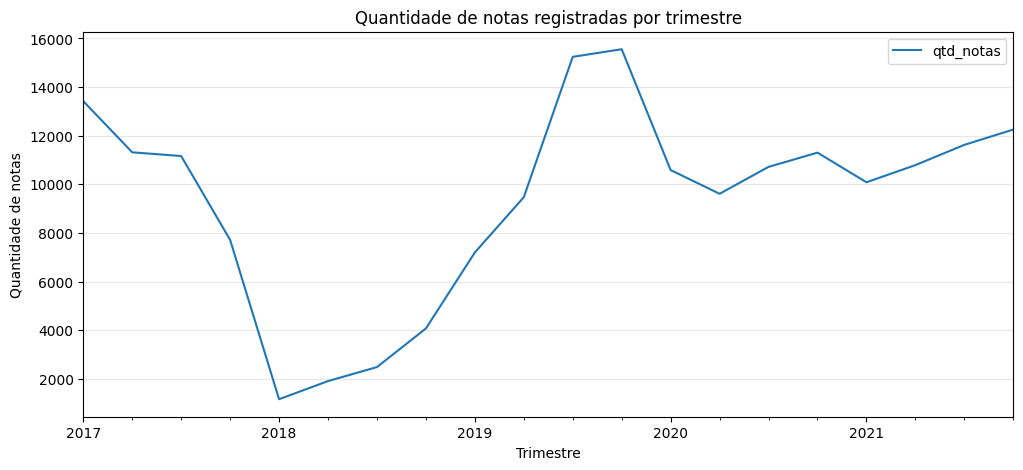

In [15]:
# Criar período trimestral para análise no tempo

df['periodo_trimestre'] = df['Data Emissão'].dt.to_period('Q').dt.to_timestamp()

# Quantidade de notas registradas por trimestre
qtd_notas_tempo = (
    df
    .groupby('periodo_trimestre')
    .agg(qtd_notas=('No.', 'count'))
)

print('Quantidade de notas registradas por trimestre:')
display(qtd_notas_tempo.head())

# Gráfico da quantidade de notas por trimestre
fig, ax = plt.subplots(figsize=(12, 5))

qtd_notas_tempo.plot(ax=ax)

ax.set_title('Quantidade de notas registradas por trimestre')
ax.set_xlabel('Trimestre')
ax.set_ylabel('Quantidade de notas')
ax.grid(axis='y', alpha=0.3)

plt.show()

Quantidade de notas por categoria e por trimestre:


,periodo_trimestre,categoria,qtd_notas
0,2017-01-01,Alimentos,1285
1,2017-01-01,Auto posto,744
2,2017-01-01,Construção,1410
3,2017-01-01,Farmácia,639
4,2017-01-01,Mercado,1344


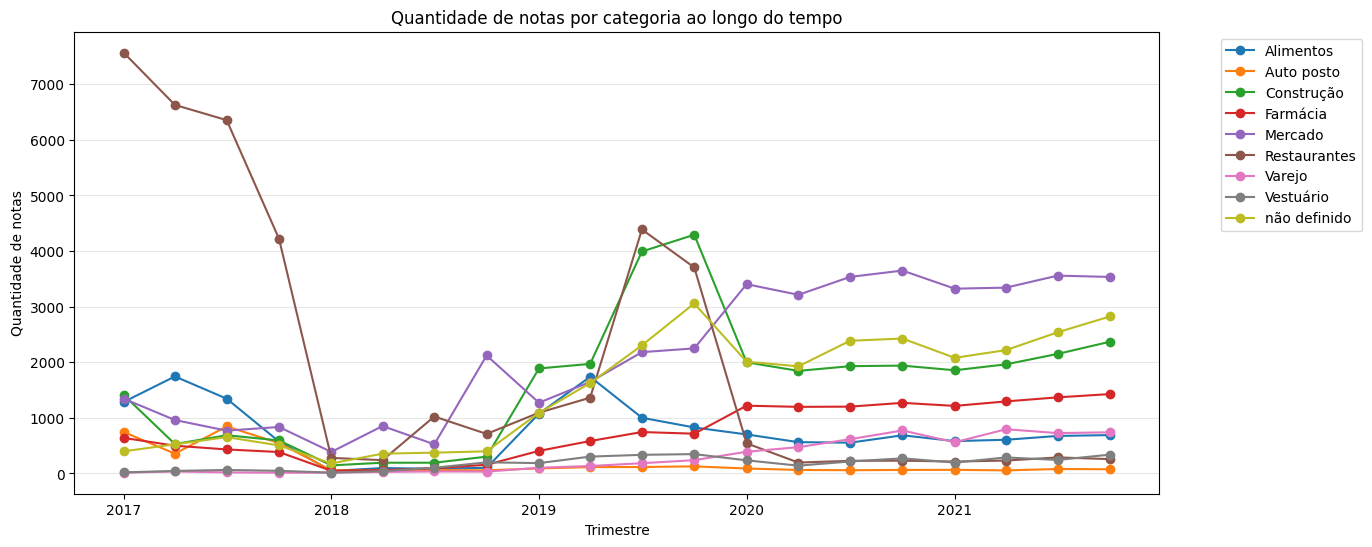

In [16]:
# Quantidade de notas por categoria e por trimestre

qtd_notas_categoria_tempo = (
    df
    .groupby(['periodo_trimestre', 'categoria'])
    .agg(qtd_notas=('No.', 'count'))
    .reset_index()
)

print('Quantidade de notas por categoria e por trimestre:')
display(qtd_notas_categoria_tempo.head())

# Gráfico da quantidade de notas por categoria ao longo do tempo
fig, ax = plt.subplots(figsize=(14, 6))

for categoria in qtd_notas_categoria_tempo['categoria'].unique():
    dados_categoria = qtd_notas_categoria_tempo[
        qtd_notas_categoria_tempo['categoria'] == categoria
    ]
    ax.plot(
        dados_categoria['periodo_trimestre'],
        dados_categoria['qtd_notas'],
        marker='o',
        label=categoria
    )

ax.set_title('Quantidade de notas por categoria ao longo do tempo')
ax.set_xlabel('Trimestre')
ax.set_ylabel('Quantidade de notas')
ax.grid(axis='y', alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

Proporção de notas com crédito por categoria e por trimestre:


,periodo_trimestre,categoria,qtd_notas,qtd_credito,prop_credito
0,2017-01-01,Alimentos,1285,1268,0.986770
1,2017-01-01,Auto posto,744,2,0.002688
2,2017-01-01,Construção,1410,107,0.075887
3,2017-01-01,Farmácia,639,132,0.206573
4,2017-01-01,Mercado,1344,235,0.174851


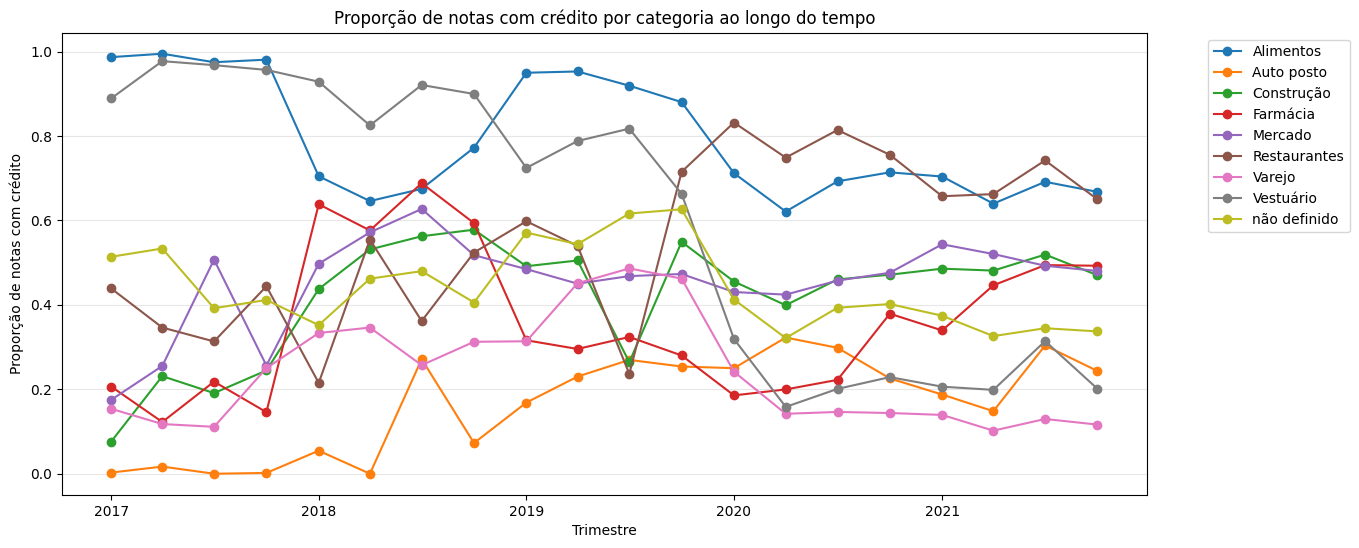

In [17]:
# Proporção de notas com crédito por categoria e por trimestre

prop_credito_categoria_tempo = (
    df
    .groupby(['periodo_trimestre', 'categoria'])
    .agg(
        qtd_notas=('No.', 'count'),
        qtd_credito=('flag_credito', 'sum'),
        prop_credito=('flag_credito', 'mean')
    )
    .reset_index()
)

print('Proporção de notas com crédito por categoria e por trimestre:')
display(prop_credito_categoria_tempo.head())

# Gráfico da proporção de notas com crédito por categoria ao longo do tempo
fig, ax = plt.subplots(figsize=(14, 6))

for categoria in prop_credito_categoria_tempo['categoria'].unique():
    dados_categoria = prop_credito_categoria_tempo[
        prop_credito_categoria_tempo['categoria'] == categoria
    ]
    ax.plot(
        dados_categoria['periodo_trimestre'],
        dados_categoria['prop_credito'],
        marker='o',
        label=categoria
    )

ax.set_title('Proporção de notas com crédito por categoria ao longo do tempo')
ax.set_xlabel('Trimestre')
ax.set_ylabel('Proporção de notas com crédito')
ax.grid(axis='y', alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

## Avalie o WOE e o IV no tempo

Avalie o WOE e o IV no tempo da variável ```categoria```.

In [18]:
# Avaliar WOE e IV da variável categoria ao longo do tempo

woe_iv_categoria_tempo = []

for periodo in sorted(df['periodo_trimestre'].dropna().unique()):
    
    df_periodo = df[df['periodo_trimestre'] == periodo].copy()
    
    tab = pd.crosstab(
        df_periodo['categoria'],
        df_periodo['flag_credito']
    )
    
    # Garantir que existam as colunas 0 e 1
    if 0 not in tab.columns:
        tab[0] = 0
        
    if 1 not in tab.columns:
        tab[1] = 0
    
    tab = tab[[0, 1]]
    
    tab['total'] = tab[0] + tab[1]
    
    # Suavização para evitar divisão por zero
    tab['pct_evento'] = (tab[1] + 0.5) / (tab[1].sum() + 0.5 * tab.shape[0])
    tab['pct_nao_evento'] = (tab[0] + 0.5) / (tab[0].sum() + 0.5 * tab.shape[0])
    
    tab['WOE'] = np.log(tab['pct_evento'] / tab['pct_nao_evento'])
    tab['IV'] = (tab['pct_evento'] - tab['pct_nao_evento']) * tab['WOE']
    
    tab['periodo_trimestre'] = periodo
    
    woe_iv_categoria_tempo.append(tab.reset_index())

woe_iv_categoria_tempo = pd.concat(woe_iv_categoria_tempo, ignore_index=True)

print('WOE e IV da variável categoria ao longo do tempo:')
display(woe_iv_categoria_tempo.head())

WOE e IV da variável categoria ao longo do tempo:


flag_credito,categoria,0,1,total,pct_evento,pct_nao_evento,WOE,IV,periodo_trimestre
0,Alimentos,17,1268,1285,0.239679,0.002151,4.713213,1.119518,2017-01-01
1,Auto posto,742,2,744,0.000472,0.091278,-5.263909,0.477992,2017-01-01
2,Construção,1303,107,1410,0.020312,0.160243,-2.065494,0.289028,2017-01-01
3,Farmácia,507,132,639,0.025035,0.062389,-0.913091,0.034107,2017-01-01
4,Mercado,1109,235,1344,0.044497,0.136394,-1.120130,0.102937,2017-01-01


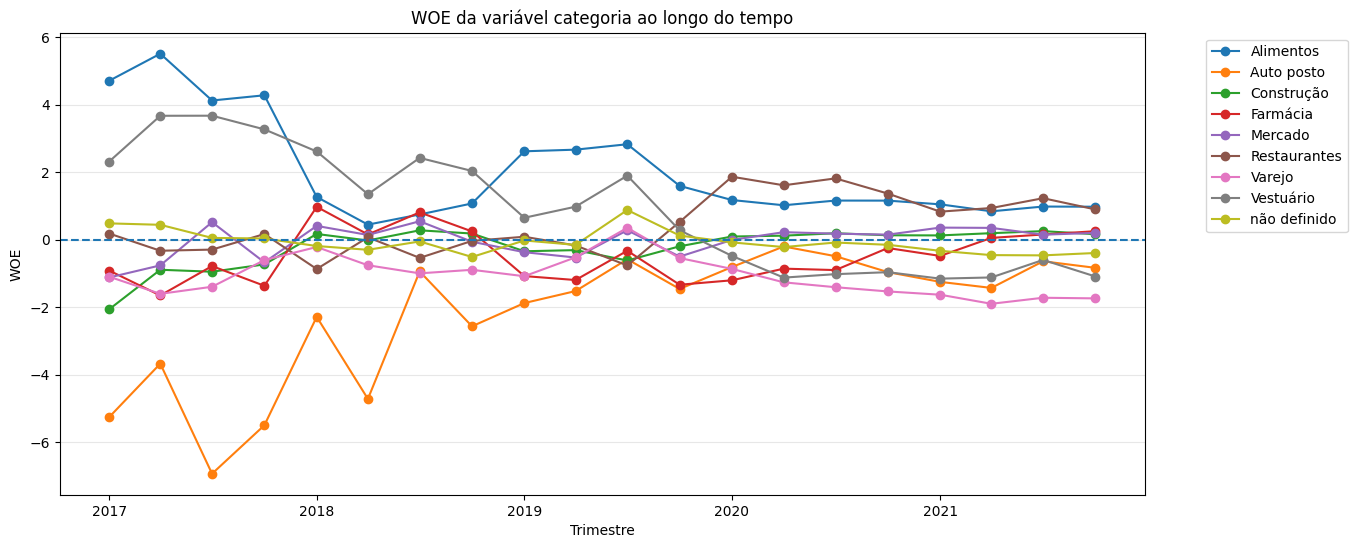

In [19]:
# Gráfico do WOE da variável categoria ao longo do tempo

fig, ax = plt.subplots(figsize=(14, 6))

for categoria in woe_iv_categoria_tempo['categoria'].unique():
    dados_categoria = woe_iv_categoria_tempo[
        woe_iv_categoria_tempo['categoria'] == categoria
    ]
    
    ax.plot(
        dados_categoria['periodo_trimestre'],
        dados_categoria['WOE'],
        marker='o',
        label=categoria
    )

ax.axhline(0, linestyle='--')
ax.set_title('WOE da variável categoria ao longo do tempo')
ax.set_xlabel('Trimestre')
ax.set_ylabel('WOE')
ax.grid(axis='y', alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

IV total da variável categoria por trimestre:


,IV_total
periodo_trimestre,
2017-01-01,2.057833
2017-04-01,2.455506
2017-07-01,2.287986
2017-10-01,1.627305
2018-01-01,0.549036


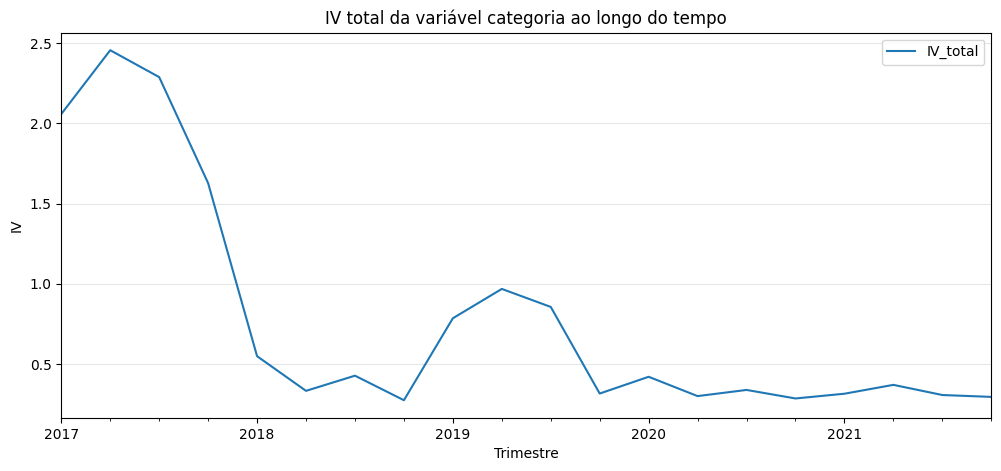

In [20]:
# IV total da variável categoria por trimestre

iv_categoria_tempo = (
    woe_iv_categoria_tempo
    .groupby('periodo_trimestre')
    .agg(IV_total=('IV', 'sum'))
)

print('IV total da variável categoria por trimestre:')
display(iv_categoria_tempo.head())

# Gráfico do IV total da categoria ao longo do tempo
fig, ax = plt.subplots(figsize=(12, 5))

iv_categoria_tempo.plot(ax=ax)

ax.set_title('IV total da variável categoria ao longo do tempo')
ax.set_xlabel('Trimestre')
ax.set_ylabel('IV')
ax.grid(axis='y', alpha=0.3)

plt.show()

## Conclua

- Quais categorias parece ter maior proporção de notas com retornos maiores que zero?
- Essas diferenças são estáveis no tempo?

Dicas:<br>
- Considere que a quantidade de notas vem aumentando
- Considere que há períodos bem atípicos no histórico
- Considere que a partir de janeiro de 2020 o público é mais parecido com o público atual (2022), seja por pandemia, seja por crescimento do público, e considere os dados dessa data em diante na sua conclusão.

Pela análise da proporção de notas com crédito positivo por categoria ao longo do tempo, observa-se que algumas categorias apresentam maior associação com o evento analisado. As categorias `Alimentos` e `Restaurantes` aparecem com proporções mais elevadas em boa parte dos períodos, indicando maior concentração de notas com crédito positivo. Por outro lado, categorias como `Auto posto` e `Varejo` tendem a apresentar proporções menores em vários trimestres.

Ao observar o gráfico do WOE no tempo, percebe-se que as diferenças entre as categorias não são totalmente estáveis. Nos períodos iniciais da base, especialmente em 2017, há oscilações mais fortes em algumas categorias, indicando comportamento atípico ou maior instabilidade histórica. Com o passar do tempo, principalmente a partir de 2020, os valores de WOE ficam menos extremos e apresentam comportamento mais próximo entre os períodos.

O gráfico do IV total da variável `categoria` ao longo do tempo reforça essa interpretação. Nos primeiros trimestres, o IV apresenta valores muito elevados, mostrando forte instabilidade no início da série. A partir de 2018 e, principalmente, de 2020 em diante, o IV fica em níveis mais moderados, indicando que a variável ainda possui poder de discriminação, mas com menor oscilação em relação aos períodos iniciais.

Portanto, conclui-se que a variável `categoria` possui relação com a ocorrência de crédito positivo, mas essa relação varia ao longo do tempo. As categorias ligadas à alimentação tendem a apresentar maior proporção de crédito positivo, enquanto outras categorias apresentam menor associação com o evento. No entanto, como há períodos atípicos e oscilações no WOE e no IV, é importante considerar a estabilidade temporal antes de utilizar essa variável em uma modelagem.